In [1]:
import pandas as pd
import numpy as np
import math
import gc
import re
from pathlib import Path
from math import sqrt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

from collections import deque
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_datareader.data as web  
from pandas import read_csv
import yfinance as yf

# Download dei dati

In [2]:

START = "2014-01-01"
END   = "2024-12-31"

yahoo_tickers = {
    'DAX':     '^GDAXI',
    'SP500':   '^GSPC',
    'OIL':     'BZ=F',
    'GOLD':    'GC=F',
    'USD_EUR': 'EUR=X',  
}
raw = yf.download(
    list(yahoo_tickers.values()),
    start=START, end=END,
    auto_adjust=True,
)
ren = {v: k for k, v in yahoo_tickers.items()}


close = raw['Close'].rename(columns=ren)[list(yahoo_tickers.keys())]

volume = raw['Volume'].rename(columns=ren)
vol_cols = [c for c in ['DAX', 'SP500'] if c in volume.columns]
volume = volume[vol_cols].add_prefix('VOL_')


#  VOLATILITA'
ret_dax = close['DAX'].pct_change()
realized_vol = (ret_dax.rolling(21).std() * np.sqrt(252)).rename('REALIZED_VOL_DAX')

implied_vol = None
for tkr in ['^V2TX', 'V2TX.DE', '^VDAX', '^V1X']:   # VSTOXX / VDAX-NEW (storico Yahoo incerto)
    try:
        iv = yf.download(tkr, start=START, end=END, auto_adjust=True)['Close']
        if iv.notna().sum().item() > 250:           # almeno ~1 anno di dati validi
            implied_vol = iv.squeeze().rename('IMPLIED_VOL_EU')
            print(f"[VOL] implied vol europea da {tkr}: {implied_vol.notna().sum()} osservazioni")
            break
    except Exception as e:
        print(f"[VOL] {tkr} non disponibile: {type(e).__name__}")
if implied_vol is None:
    print("[VOL] nessuna implied vol europea trovata su Yahoo: uso solo la realized vol del DAX")

yahoo_data = close.join(volume).join(realized_vol)
if implied_vol is not None:
    yahoo_data = yahoo_data.join(implied_vol)


#  MACRO (FRED)
fred_tickers = {
    'TASSO_3M_DE':  'IR3TIB01DEM156N',     # tasso 3-mese
    'YIELD_10Y_DE': 'IRLTLT01DEM156N',     # yield 10Y bund
    'CPI_DE':       'DEUCPIALLAINMEI',     # inflazione (headline)
    'CORE_CPI_DE':  'DEUCPICORMINMEI',     # inflazione core (no food & energy)
    'INDPROD_DE':   'DEUPROINDMISMEI',     # produzione industriale
    'UNEMP_DE':     'LRHUTTTTDEM156S',     # tasso di disoccupazione (armonizzato)
    'M3_DE':        'MABMM301DEM189S',     # massa monetaria
}

fred_cols = {}
missing = []
for name, code in fred_tickers.items():
    try:
        s = web.DataReader(code, 'fred', start=START, end=END)
        fred_cols[name] = s[code]
    except Exception as e:
        missing.append((name, code))
        print(f"[FRED] saltata {name} ({code}): {type(e).__name__}")
if missing:
    print("Serie FRED non disponibili:", missing)
fred_data = pd.DataFrame(fred_cols)


# MERGE giornaliero 

fred_daily = fred_data.resample('D').ffill()
df = yahoo_data.join(fred_daily, how='left')


if {'YIELD_10Y_DE', 'TASSO_3M_DE'}.issubset(df.columns):
    df['TERM_SPREAD_DE'] = df['YIELD_10Y_DE'] - df['TASSO_3M_DE']

df = df.ffill().dropna()
print(df.shape, df.columns.tolist())
df.to_csv('neuneier_data2.csv')


[*********************100%***********************]  5 of 5 completed
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^V2TX"}}}
$^V2TX: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^V2TX']: possibly delisted; no timezone found
$V2TX.DE: possibly delisted; no price data found  (1d 2014-01-01 -> 2024-12-31)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['V2TX.DE']: possibly delisted; no price data found  (1d 2014-01-01 -> 2024-12-31)
$^VDAX: possibly delisted; no price data found  (1d 2014-01-01 -> 2024-12-31)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^VDAX']: possibly delisted; no price data found  (1d 2014-01-01 -> 2024-12-31)
$^V1X: possibly delisted; no price data found  (1d 2014-01-01 -> 2024-12-31)
[*********************100%******************

[VOL] nessuna implied vol europea trovata su Yahoo: uso solo la realized vol del DAX
[FRED] saltata M3_DE (MABMM301DEM189S): RemoteDataError
Serie FRED non disponibili: [('M3_DE', 'MABMM301DEM189S')]
(2847, 15) ['DAX', 'SP500', 'OIL', 'GOLD', 'USD_EUR', 'VOL_DAX', 'VOL_SP500', 'REALIZED_VOL_DAX', 'TASSO_3M_DE', 'YIELD_10Y_DE', 'CPI_DE', 'CORE_CPI_DE', 'INDPROD_DE', 'UNEMP_DE', 'TERM_SPREAD_DE']


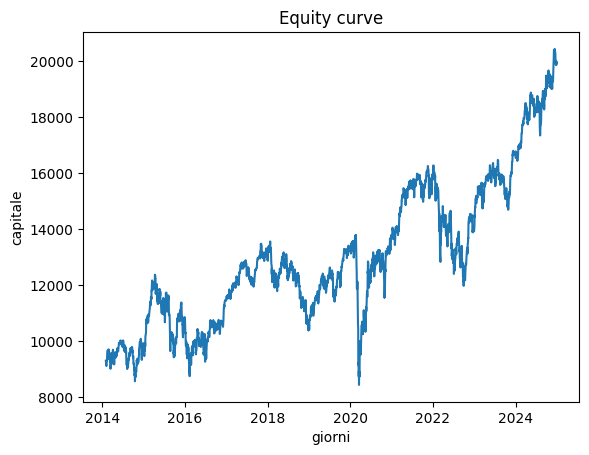

In [3]:




if len(df["DAX"]) > 0:
    dax=df["DAX"]
else:
    dax=read_csv('neuneier_data.csv', index_col=0, parse_dates=True)["DAX"]
   

plt.plot(dax.loc[START:END])         
plt.title("Equity curve")
plt.xlabel("giorni")
plt.ylabel("capitale")
plt.show()

def makeEquityLine(result,benckmark):

    plt.plot(result, label="Q-learning")    
    plt.plot(benckmark, label="BuyAndHold")     
    plt.title("Equity curve")
    plt.xlabel("giorni")
    plt.ylabel("capitale")
    plt.show()


# Costruzione della Rete

In [4]:

# RETE QLU (Neuneier)

STATE_COLS  = [c for c in df.columns if c != "DAX"]
NFEATURE    = len(STATE_COLS)    
#ALLOCAZIONI = [0.0, 1.0]  
#ALLOCAZIONI = [0.0, 1.0, -1]    
ALLOCAZIONI = [0.0, 0.25, 0.5, 0.75, 1.0]      
#ALLOCAZIONI = [0.0, 0.25, 0.5, 0.75, 1.0, 1.2, 1.4, 1.6, 1.8, 2]     

class QNN(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features + 1, hidden),  
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),                
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)           

rete=QNN(NFEATURE)

#helper

# dato un batch di feature e un batch di posizioni, le passa alla rete e restituisce i Q-value corrispondenti
def q_value(net, feat, pos):
    x = torch.cat([feat, pos.unsqueeze(1)], dim=1)  
    return net(x)                                    

# --- helper 2: simulazione del portafogio con la rete freezzata
@torch.no_grad()
def simula(net, feat, rend, commission, start_pos=0.0):
    # per ogni giorno sceglie K' che massimizza Q(s,K') - costo di switch
    pos = start_pos
    equity = [1.0]
    azioni = []
    for t in range(len(rend)):
        s_t = torch.tensor(feat[t], dtype=torch.float32).unsqueeze(0)   # [1, F]
        best_val, best_K = -1e18, pos
        for Kp in ALLOCAZIONI:
            q   = q_value(net, s_t, torch.tensor([Kp], dtype=torch.float32)).item()
            val = q - commission * abs(Kp - pos)
            if val > best_val:
                best_val, best_K = val, Kp
        r = best_K * rend[t] - commission * abs(best_K - pos)   # rendimento realizzato del giorno
        equity.append(equity[-1] * (1 + r))
        azioni.append(best_K)
        pos = best_K
    return np.array(equity), np.array(azioni)




# Stampa risultati e grafici

In [5]:
# ═══════════════════════════════════════════════════════════════
# FUNZIONE MODULARE: confronto agente vs buy & hold
#   stampa metriche (rendimento, Sharpe, max drawdown) e disegna
#   equity (sopra) + drawdown (sotto) [+ loss, se passata].
#   Usata sia sul TRAIN che sul TEST.
#   Se nome_file != None -> salva anche gli ordini in CSV nella cartella
#   results/ (nomenclatura: ResultsOOSNNQLU / ResultsOOSPolicy):
#     - {nome_file}.csv           -> ordini/operazioni giorno per giorno
#     - {nome_file}_riepilogo.csv -> metriche riassuntive
# ═══════════════════════════════════════════════════════════════
def mostra_risultati(eq_agente, eq_bench, titolo="", capitale=100000, azioni=None,
                     loss_hist=None, nome_file=None, indice=None):
    eq_a = np.asarray(eq_agente, dtype=float)
    eq_b = np.asarray(eq_bench,  dtype=float)

    def _sharpe(eq):
        ret = eq[1:] / eq[:-1] - 1
        return np.sqrt(252) * ret.mean() / (ret.std() + 1e-9)

    def _dd(eq):
        picco = np.maximum.accumulate(eq)
        return (eq - picco) / picco

    dd_a, dd_b = _dd(eq_a), _dd(eq_b)

    # --- metriche ---
    print(f"===== {titolo} =====")
    print(f"{'':<14}{'Agente':>15}{'Buy & Hold':>17}")
    print(f"{'Capitale':<14}{capitale*eq_a[-1]:>14,.0f}€{capitale*eq_b[-1]:>16,.0f}€")
    print(f"{'Rendimento':<14}{eq_a[-1]-1:>14.1%}{eq_b[-1]-1:>17.1%}")
    print(f"{'Sharpe':<14}{_sharpe(eq_a):>15.2f}{_sharpe(eq_b):>17.2f}")
    print(f"{'Max drawdown':<14}{dd_a.min():>14.1%}{dd_b.min():>17.1%}")
    if azioni is not None:
        print(f"{'% investito':<14}{np.mean(azioni):>15.1%}{1.0:>17.1%}")

    # --- grafici: equity + drawdown (+ loss se fornita) ---
    n_panel = 3 if loss_hist is not None else 2
    fig, axes = plt.subplots(n_panel, 1, figsize=(10, 3.3 * n_panel))
    ax1, ax2 = axes[0], axes[1]

    ax1.plot(capitale * eq_a, label="Agente")
    ax1.plot(capitale * eq_b, label="Buy & Hold")
    ax1.set_title(f"Equity curve — {titolo}"); ax1.set_ylabel("capitale (€)")
    ax1.set_xlabel("giorni"); ax1.legend()

    ax2.plot(dd_a * 100, label="Agente")
    ax2.plot(dd_b * 100, label="Buy & Hold")
    ax2.fill_between(range(len(dd_a)), dd_a * 100, 0, alpha=0.15)
    ax2.set_title("Drawdown"); ax2.set_ylabel("drawdown (%)"); ax2.set_xlabel("giorni"); ax2.legend()

    # terzo pannello: curva della loss (solo se passata)
    if loss_hist is not None:
        ax3 = axes[2]
        lh = np.asarray(loss_hist, dtype=float)
        ax3.plot(lh, alpha=0.3, label="loss (grezza)")
        w = max(1, len(lh) // 200)                       # finestra media mobile
        if w > 1:
            ma = np.convolve(lh, np.ones(w) / w, mode="valid")
            ax3.plot(range(w - 1, len(lh)), ma, label=f"media mobile ({w})")
        ax3.set_yscale("log")                            # log: la loss è piccola e cala di ordini di grandezza
        ax3.set_title("Loss di training"); ax3.set_ylabel("loss (log)"); ax3.set_xlabel("iterazione"); ax3.legend()

    plt.tight_layout(); plt.show()

    # ── EXPORT CSV degli ordini (solo se richiesto) ────────────────────
    if nome_file is not None:
        import os
        CARTELLA = "/home/lucacupellaro/luca/Universita/RL/ProgettoFinale/results"
        os.makedirs(CARTELLA, exist_ok=True)

        n_op = np.nan
        if azioni is not None:
            K        = np.asarray(azioni, dtype=float)
            pos_prec = np.concatenate([[0.0], K[:-1]])        # ieri partivo da cash (0.0)
            turnover = K - pos_prec                           # variazione di posizione (segno = compra/vende)
            ret_ag   = eq_a[1:] / eq_a[:-1] - 1               # P&L giornaliero dell'agente
            ret_bh   = eq_b[1:] / eq_b[:-1] - 1               # P&L giornaliero del buy & hold
            n_op     = int(np.sum(turnover != 0))             # quante volte ho davvero operato

            tipo_pos = np.where(K > 0, "LONG", np.where(K < 0, "SHORT", "CASH"))
            tipo_op  = np.where(turnover > 0, "COMPRA", np.where(turnover < 0, "VENDE", "MANTIENE"))

            operazioni = pd.DataFrame({
                "giorno":             np.arange(1, len(K) + 1),
                "allocazione_K":      K,
                "posizione_prec":     pos_prec,
                "turnover":           turnover,
                "operazione":         tipo_op,
                "posizione":          tipo_pos,
                "rendimento_giorno":  ret_ag,
                "rendimento_buyhold": ret_bh,
                "equity_agente":      capitale * eq_a[1:],
                "equity_buyhold":     capitale * eq_b[1:],
                "drawdown_agente":    dd_a[1:],
            })

            # se ho l'indice temporale, aggiungo la data reale in prima colonna
            if indice is not None:
                idx_vals = np.asarray(indice)
                if len(idx_vals) == len(K) + 1:
                    operazioni.insert(0, "data", idx_vals[:-1])
                elif len(idx_vals) == len(K):
                    operazioni.insert(0, "data", idx_vals)
        else:
            operazioni = pd.DataFrame({
                "giorno":          np.arange(len(eq_a)),
                "equity_agente":   capitale * eq_a,
                "equity_buyhold":  capitale * eq_b,
                "drawdown_agente": dd_a,
            })

        riepilogo = pd.DataFrame({
            "metrica": ["titolo", "capitale_finale_agente", "capitale_finale_bh",
                        "rendimento_agente", "rendimento_bh", "sharpe_agente", "sharpe_bh",
                        "max_drawdown_agente", "max_drawdown_bh", "%_investito_medio", "n_operazioni"],
            "valore":  [titolo, capitale * eq_a[-1], capitale * eq_b[-1],
                        eq_a[-1] - 1, eq_b[-1] - 1, _sharpe(eq_a), _sharpe(eq_b),
                        dd_a.min(), dd_b.min(),
                        (np.mean(azioni) if azioni is not None else np.nan), n_op],
        })

        percorso_ord = os.path.join(CARTELLA, f"{nome_file}.csv")
        percorso_rie = os.path.join(CARTELLA, f"{nome_file}_riepilogo.csv")
        operazioni.to_csv(percorso_ord, index=False)
        riepilogo.to_csv(percorso_rie, index=False)
        print(f"[CSV] ordini:    {percorso_ord}  ({len(operazioni)} righe, {n_op} operazioni)")
        print(f"[CSV] riepilogo: {percorso_rie}")


# Ambiente di simulazione trading

In [6]:
class Env():
    def __init__(self,history_price,features):
        self.history_price=history_price
        self.features=features
        self.balance=100000
        self.commission=0.001          
        self.current_step = 0
        self.position = 0.0            # frazione attualmente investita nel DAX

    def step(self,action):

        t=self.current_step

        peso = ALLOCAZIONI[action]                 

        prezzo_oggi = self.history_price[t]
        prezzo_domani = self.history_price[t+1]

        rendimento= prezzo_domani/prezzo_oggi - 1  

        costo = self.commission*abs(peso - self.position)  
        rewards = peso*rendimento - costo  

        self.balance *= (1 + rewards)     

        self.position = peso
        self.current_step += 1                    
        s_next = self.features[self.current_step]
        done = (self.current_step >= len(self.history_price) - 1)

        return s_next, rewards, done
    
    def reset(self):

        self.balance=100000
        self.current_step = 0
        self.position = 0.0
        return self.features[0]


# Setup della rete

In [7]:

GAMMA       = 0.99
LR          = 3e-4
TARGET_SYNC = 500         # ogni quante iter copio rete -> target  (il "Q^(k)" del paper)
COMMISSION  = 0.001       # costo di transazione (pagato quando cambio posizione)


#inizializzo la rete Q e l'ottimizzatore
rete=QNN(NFEATURE)
optimizer = torch.optim.Adam(rete.parameters(), lr=LR)

#suddivisone train e test
index    = int(len(df) * 0.6)
training = df.iloc[:index]
test     = df.iloc[index:]

# statistiche di normalizzazione: SOLO dal train (niente look-ahead)
mu, sd = training[STATE_COLS].mean(), training[STATE_COLS].std()

# array di TRAIN
feat_train  = ((training[STATE_COLS] - mu) / sd).values.astype(np.float32)  
price_train = training["DAX"].values.astype(np.float32)
rend_train  = price_train[1:] / price_train[:-1] - 1                       

# array di TEST 
feat_test  = ((test[STATE_COLS] - mu) / sd).values.astype(np.float32)
price_test = test["DAX"].values.astype(np.float32)
rend_test  = price_test[1:] / price_test[:-1] - 1

print("train feat:", feat_train.shape, "| test feat:", feat_test.shape)


train feat: (1708, 14) | test feat: (1139, 14)


# Training della Rete 

iter   2000 | loss 0.000358 | train return  +26.8% | balance      126,833€ | %DAX 46.0%
iter   4000 | loss 0.000070 | train return +127.4% | balance      227,372€ | %DAX 73.6%
iter   6000 | loss 0.000058 | train return +303.2% | balance      403,172€ | %DAX 72.1%
iter   8000 | loss 0.000055 | train return +364.7% | balance      464,651€ | %DAX 79.7%
iter  10000 | loss 0.000052 | train return +487.6% | balance      587,592€ | %DAX 66.3%
iter  12000 | loss 0.000054 | train return +606.3% | balance      706,291€ | %DAX 62.3%
iter  14000 | loss 0.000052 | train return +847.9% | balance      947,890€ | %DAX 62.7%
iter  16000 | loss 0.000051 | train return +819.0% | balance      919,007€ | %DAX 50.9%
iter  18000 | loss 0.000048 | train return +649.7% | balance      749,737€ | %DAX 50.3%
iter  20000 | loss 0.000049 | train return +888.4% | balance      988,356€ | %DAX 61.7%
--> Convergenza raggiunta a iter 20000 (Δloss < 1e-06)
===== TRAIN (fine training) =====
                       Agente  

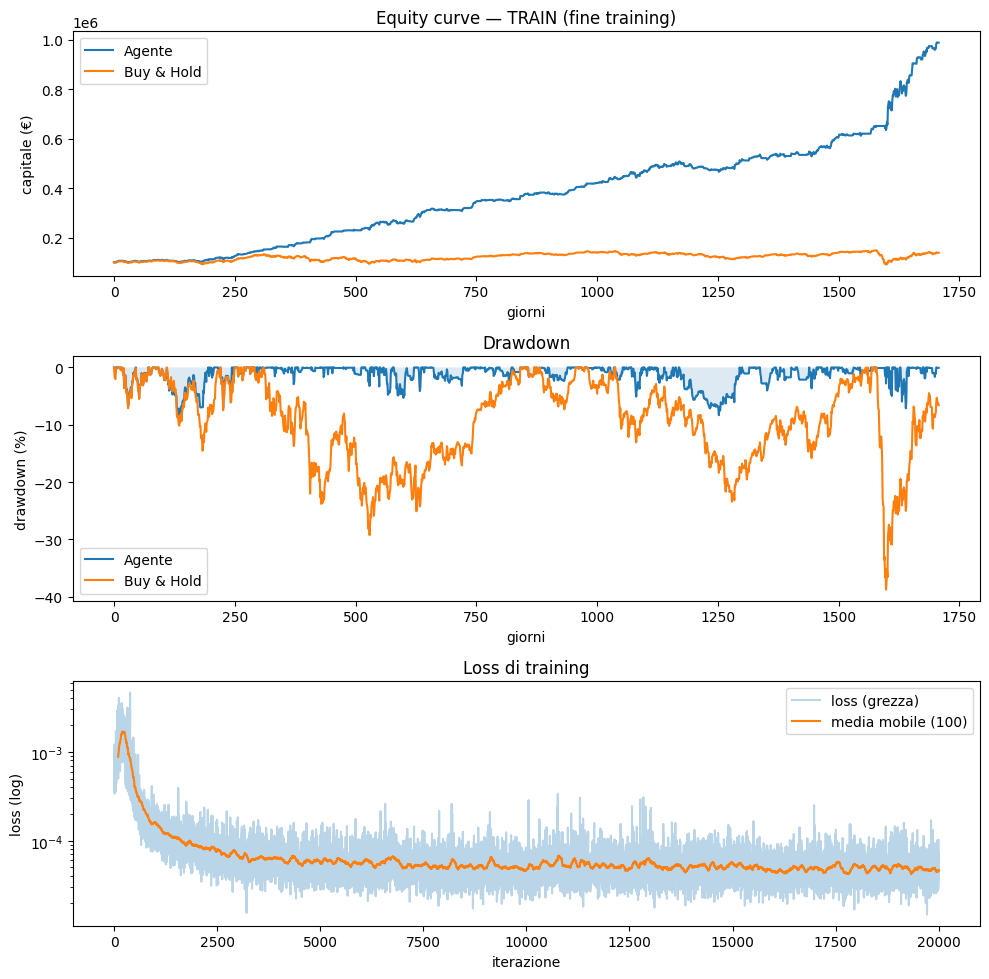

In [8]:

CAPITALE_INIZIALE = 100000
MAX_ITER    = 100000      # (evita loop infinito se non converge)
CHECK_EVERY = 2000        # ogni quanto controllo convergenza + stampo
DELTA       = 1e-6        # soglia: se la loss media cambia meno di DELTA -> convergiuto


T = len(rend_train)
loss_hist = []

it  = 0
run = True
loss_media_prec = None

while run:
    it += 1

    #step 1
    idx = np.random.randint(0, T, size=64)
    K_t = np.random.choice(ALLOCAZIONI, size=64).astype(np.float32)

    s_t    = torch.tensor(feat_train[idx])
    s_next = torch.tensor(feat_train[idx + 1])
    rend   = torch.tensor(rend_train[idx])
    Kt     = torch.tensor(K_t)

    #step 2
    with torch.no_grad():
        candidati = []
        for Kp in ALLOCAZIONI:
            Kp_t = torch.full((64,), float(Kp))
            q    = q_value(rete, s_next, Kp_t)
            cost = COMMISSION * torch.abs(Kp_t - Kt)
            candidati.append(q - cost)
        best   = torch.stack(candidati, dim=1).max(dim=1).values
        target = Kt * rend + GAMMA * best 

    pred = q_value(rete, s_t, Kt)

    #step 3
    d    = target - pred
    loss = d.pow(2).mean()
    optimizer.zero_grad()

    #step 4
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())

    # STEP 5 (convergenza) ogni CHECK_EVERY
    if it % CHECK_EVERY == 0:
        loss_media = np.mean(loss_hist[-CHECK_EVERY:])
        eq, az     = simula(rete, feat_train, rend_train, COMMISSION)
        balance    = CAPITALE_INIZIALE * eq[-1]
        print(f"iter {it:6d} | loss {loss_media:.6f} "
              f"| train return {eq[-1]-1:+7.1%} | balance {balance:>12,.0f}€ "
              f"| %DAX {np.mean(az):5.1%}")
        if loss_media_prec is not None and abs(loss_media_prec - loss_media) < DELTA:
            print(f"--> Convergenza raggiunta a iter {it} (Δloss < {DELTA})")
            run = False
        loss_media_prec = loss_media

    if it >= MAX_ITER:
        print(f"--> Raggiunto MAX_ITER ({MAX_ITER}) senza convergenza")
        run = False

# metriche e grafici dell'ultima iterazione
eq_tr, az_tr = simula(rete, feat_train, rend_train, COMMISSION)
bh_tr        = price_train / price_train[0]
mostra_risultati(eq_tr, bh_tr, titolo="TRAIN (fine training)",
                 capitale=CAPITALE_INIZIALE, azioni=az_tr, loss_hist=loss_hist)


===== TEST OOS (2020-08-19 -> 2024-12-30) =====
                       Agente       Buy & Hold
Capitale             106,368€         153,415€
Rendimento              6.4%            53.4%
Sharpe                   0.18             0.65
Max drawdown          -21.5%           -26.4%
% investito             39.4%           100.0%


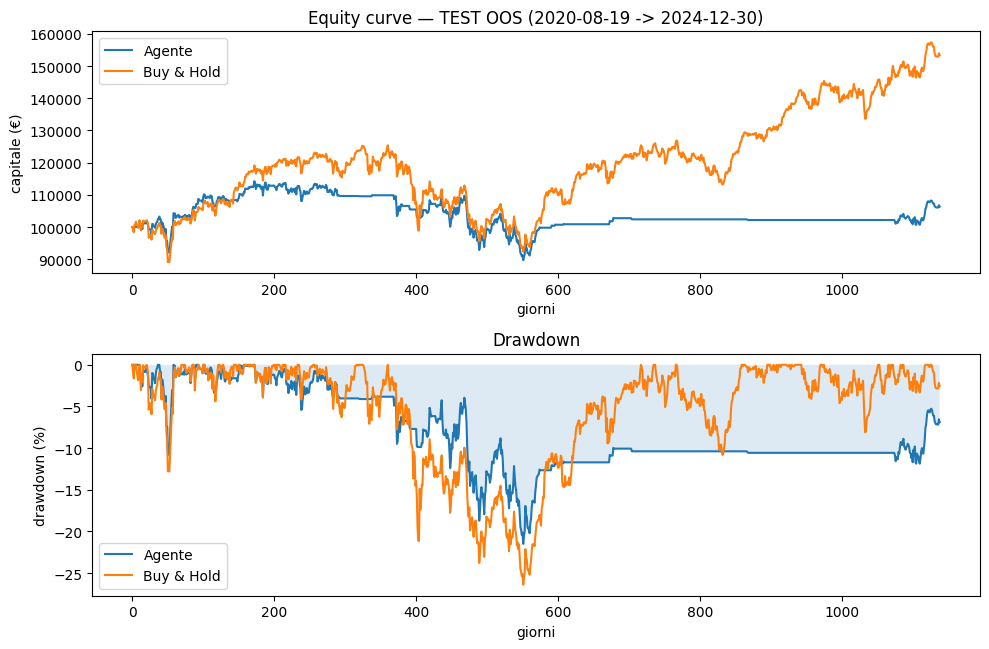

[CSV] ordini:    /home/lucacupellaro/luca/Universita/RL/ProgettoFinale/results/ResultsOOSNNQLU.csv  (1138 righe, 141 operazioni)
[CSV] riepilogo: /home/lucacupellaro/luca/Universita/RL/ProgettoFinale/results/ResultsOOSNNQLU_riepilogo.csv


In [9]:

# INFERENZA: rete ADDESTRATA (pesi congelati) applicata al TEST
CAPITALE_INIZIALE = 100000

eq_test, az_test = simula(rete, feat_test, rend_test, COMMISSION)   # policy greedy OOS
bh_test          = price_test / price_test[0]                       # buy & hold sul test

mostra_risultati(eq_test, bh_test,
                 titolo=f"TEST OOS ({test.index[0].date()} -> {test.index[-1].date()})",
                 capitale=CAPITALE_INIZIALE, azioni=az_test,
                 nome_file="ResultsOOSNNQLU", indice=test.index)


policy-iter  0 | azioni cambiate 64.3% | train return +425.1% | %DAX 61.4% | loss 0.000131
policy-iter  1 | azioni cambiate 51.1% | train return +868.0% | %DAX 57.2% | loss 0.000055
policy-iter  2 | azioni cambiate 43.2% | train return +1378.2% | %DAX 55.1% | loss 0.000047
policy-iter  3 | azioni cambiate 37.1% | train return +2081.0% | %DAX 58.1% | loss 0.000043
policy-iter  4 | azioni cambiate 32.6% | train return +2298.0% | %DAX 51.7% | loss 0.000043
policy-iter  5 | azioni cambiate 32.8% | train return +2592.2% | %DAX 54.2% | loss 0.000043
policy-iter  6 | azioni cambiate 30.4% | train return +2966.7% | %DAX 54.0% | loss 0.000044
policy-iter  7 | azioni cambiate 28.6% | train return +2547.2% | %DAX 57.3% | loss 0.000043
policy-iter  8 | azioni cambiate 30.0% | train return +3056.6% | %DAX 57.7% | loss 0.000043
policy-iter  9 | azioni cambiate 28.0% | train return +4059.8% | %DAX 53.9% | loss 0.000041
policy-iter 10 | azioni cambiate 31.0% | train return +4159.1% | %DAX 54.7% | loss

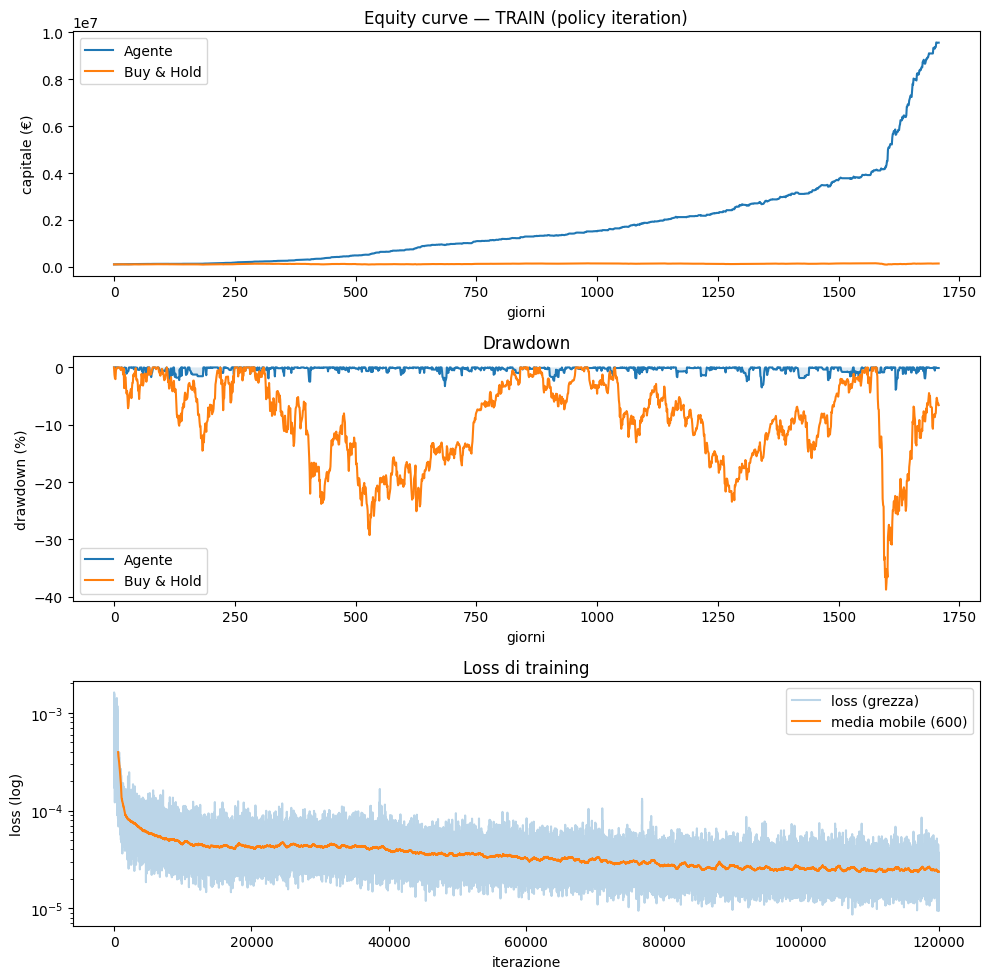

In [10]:

# MODEL-FREE POLICY ITERATION
# Q su una policy fissata → miglioro la policy → rivaluto → rimiglioro → fino a convergenza



CAPITALE_INIZIALE = 100000

# INIT: reinizializzo reti nuove (architettura QNN)
rete          = QNN(NFEATURE)                      
optimizer     = torch.optim.Adam(rete.parameters(), lr=LR)
policy_net    = QNN(NFEATURE)                        
policy_net.load_state_dict(rete.state_dict())       
policy_net.eval()
target_net_pi = QNN(NFEATURE)                       
target_net_pi.eval()

ALLOC_T = torch.tensor(ALLOCAZIONI, dtype=torch.float32)   

# iperparametri
N_POLICY_ITER = 30        # max iterazioni di policy iteration (i)
EVAL_STEPS    = 4000      # passi di policy evaluation per ogni i
C_SYNC        = 500       # ogni quanti passi  w_target <- w
EPS_MU        = 0.01      # STOP se < 1% di azioni cambiate tra mu_i e mu_{i+1}
T = len(rend_train)
loss_hist = []

for i in range(N_POLICY_ITER):

    # POLICY EVALUATION 
    target_net_pi.load_state_dict(rete.state_dict())        

    for step in range(EVAL_STEPS):
        
        idx = np.random.randint(0, T, size=64)
        K_t = np.random.choice(ALLOCAZIONI, size=64).astype(np.float32)

        s_t    = torch.tensor(feat_train[idx])
        s_next = torch.tensor(feat_train[idx + 1])
        rend   = torch.tensor(rend_train[idx])
        Kt     = torch.tensor(K_t)

        with torch.no_grad():
            # scelgo l'azione con la rete congelata in base arg max di Q
            val_pol = []
            for Kp in ALLOCAZIONI:
                Kp_t = torch.full((64,), float(Kp))
                qp   = q_value(policy_net, s_next, Kp_t)
                val_pol.append(qp - COMMISSION * torch.abs(Kp_t - Kt))
            a_next    = torch.stack(val_pol, dim=1).argmax(dim=1)   
            K_next    = ALLOC_T[a_next]                            
            cost_next = COMMISSION * torch.abs(K_next - Kt)

            # stima di Q stabile in base all'azione scelta dalla policy_net nello stato s+1
            q_next = q_value(target_net_pi, s_next, K_next)
            y      = Kt * rend + GAMMA * (q_next - cost_next)

        # predizione con rete VIVA
        pred = q_value(rete, s_t, Kt)
        d    = y - pred

        # aggioramento dei pesi
        loss = d.pow(2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

        if (step + 1) % C_SYNC == 0:
            target_net_pi.load_state_dict(rete.state_dict())       

    # POLICY IMPROVEMENT
    az_old = simula(policy_net, feat_train, rend_train, COMMISSION)[1]  
    policy_net.load_state_dict(rete.state_dict())                        
    eq_new, az_new = simula(policy_net, feat_train, rend_train, COMMISSION) 

    # CONTROLLO CONVERGENZA DELLA POLICY 
    frac_changed = np.mean(az_new != az_old)                            
    print(f"policy-iter {i:2d} | azioni cambiate {frac_changed:5.1%} "
          f"| train return {eq_new[-1]-1:+7.1%} | %DAX {np.mean(az_new):5.1%} "
          f"| loss {np.mean(loss_hist[-EVAL_STEPS:]):.6f}")
    if frac_changed < EPS_MU:
        print(f"--> Policy convergente a i={i}  ({frac_changed:.1%} < {EPS_MU:.0%})")
        break

#RISULTATO FINALE sul TRAIN 
eq_tr, az_tr = simula(rete, feat_train, rend_train, COMMISSION)
bh_tr        = price_train / price_train[0]
mostra_risultati(eq_tr, bh_tr, titolo="TRAIN (policy iteration)",
                 capitale=CAPITALE_INIZIALE, azioni=az_tr, loss_hist=loss_hist)


===== TEST OOS (2020-08-19 -> 2024-12-30) =====
                       Agente       Buy & Hold
Capitale              91,088€         153,415€
Rendimento             -8.9%            53.4%
Sharpe                  -0.16             0.65
Max drawdown          -20.9%           -26.4%
% investito             15.4%           100.0%


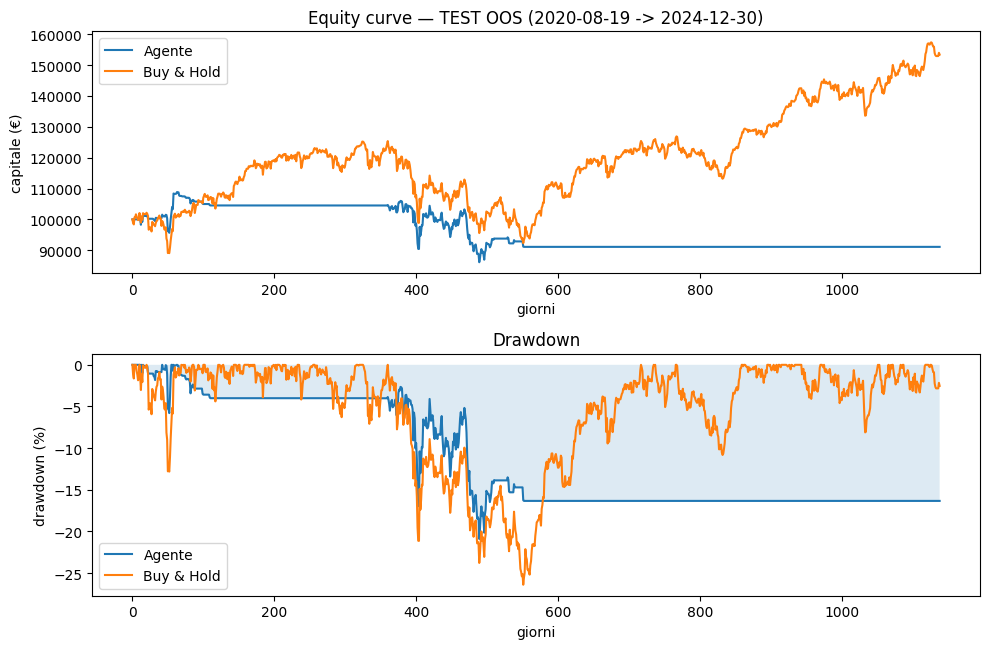

[CSV] ordini:    /home/lucacupellaro/luca/Universita/RL/ProgettoFinale/results/ResultsOOSPolicy.csv  (1138 righe, 73 operazioni)
[CSV] riepilogo: /home/lucacupellaro/luca/Universita/RL/ProgettoFinale/results/ResultsOOSPolicy_riepilogo.csv


In [11]:

# INFERENZA: rete ADDESTRATA (pesi congelati) applicata al TEST
CAPITALE_INIZIALE = 100000

eq_test, az_test = simula(policy_net, feat_test, rend_test, COMMISSION)   # policy greedy OOS
bh_test          = price_test / price_test[0]                       # buy & hold sul test

mostra_risultati(eq_test, bh_test,
                 titolo=f"TEST OOS ({test.index[0].date()} -> {test.index[-1].date()})",
                 capitale=CAPITALE_INIZIALE, azioni=az_test,
                 nome_file="ResultsOOSPolicy", indice=test.index)
